# Motif-Based Failure/Ambiguity Prediction for Attribution Graphs

This notebook demonstrates classifying Neuronpedia attribution graphs by correctness status
(verified-correct **true** vs ambiguous/unverified **unknown**) using **3-node motif spectrum features**.

**Pipeline overview:**
1. Load pre-computed motif census features (count ratios, z-scores, graph statistics)
2. Build feature matrix and within-domain deviation features
3. Train RF/LR classifiers with repeated stratified k-fold CV
4. Run difficulty prediction, per-domain analysis, feature ablation
5. Compute statistical significance (permutation test, bootstrap CI)

The demo uses 100 attribution graphs (76 true + 24 unknown) across 8 task domains.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# igraph — NOT on Colab, always install
_pip('igraph==0.11.8')

# numpy, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    # Colab versions: numpy==2.0.2, scipy==1.16.3, scikit-learn==1.6.1, matplotlib==3.10.0
    # Use latest compatible versions for local Python (scipy 1.16.3 needs Python >=3.11)
    _pip('numpy==2.0.2', 'scipy>=1.13,<2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import random
import math
import time
from collections import Counter, defaultdict

import numpy as np
import igraph
from scipy import stats
from scipy.spatial.distance import cosine as cosine_distance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, LeaveOneOut
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter3_motif_based_fai/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {data['metadata']['n_graphs']} graphs")
print(f"Features: {data['metadata']['feature_names']}")
print(f"DAG-possible motif IDs: {data['metadata']['dag_possible_motif_ids']}")

Loaded 100 graphs
Features: ['ratio_021D', 'ratio_021U', 'ratio_021C', 'ratio_030T', 'z_magnitude', 'log_n_nodes', 'log_n_edges', 'density', 'mean_in_deg', 'mean_out_deg', 'max_out_deg', 'n_layers']
DAG-possible motif IDs: [2, 4, 6, 7]


In [5]:
# ── Configuration ──
# Tunable parameters (original values from the full experiment)
SEED = 42
N_SPLITS = 5        # CV folds (original: 5)
N_REPEATS = 10      # CV repeats (original: 10)
N_ESTIMATORS = 100  # RF trees (original: 100)
N_PERMUTATIONS = 200 # permutation test iterations (original: 500, reduced for runtime)
N_BOOTSTRAP = 500   # bootstrap CI samples (original: 1000, reduced for runtime)

## Phase 0: Build Isoclass-to-MAN Mapping

Build mapping from igraph isoclass IDs to standard MAN (Mutual-Asymmetric-Null) triad labels for all 16 directed 3-node subgraphs. Identify the 4 DAG-possible motifs: 021D, 021U, 021C, 030T.

In [6]:
def build_isoclass_mapping():
    """Build mapping from igraph isoclass IDs to MAN labels for 3-node triads."""
    triads = {
        "003": [], "012": [(0, 1)], "102": [(0, 1), (1, 0)],
        "021D": [(1, 0), (1, 2)], "021U": [(0, 1), (2, 1)],
        "021C": [(0, 1), (1, 2)],
        "111D": [(0, 1), (1, 0), (2, 1)], "111U": [(0, 1), (1, 0), (1, 2)],
        "030T": [(0, 1), (0, 2), (1, 2)], "030C": [(0, 1), (1, 2), (2, 0)],
        "201": [(0, 1), (1, 0), (0, 2), (2, 0)],
        "120D": [(1, 2), (2, 1), (1, 0), (2, 0)],
        "120U": [(1, 2), (2, 1), (0, 1), (0, 2)],
        "120C": [(0, 1), (1, 0), (1, 2), (2, 0)],
        "210": [(0, 1), (1, 0), (0, 2), (2, 0), (1, 2)],
        "300": [(0, 1), (1, 0), (0, 2), (2, 0), (1, 2), (2, 1)],
    }
    isoclass_to_man = {}
    man_to_isoclass = {}
    for label, edges in triads.items():
        g = igraph.Graph(n=3, edges=edges, directed=True)
        cls_id = g.isoclass()
        isoclass_to_man[cls_id] = label
        man_to_isoclass[label] = cls_id
    assert len(isoclass_to_man) == 16
    dag_possible_labels = ["021D", "021U", "021C", "030T"]
    dag_possible_ids = sorted(man_to_isoclass[l] for l in dag_possible_labels)
    print(f"Isoclass mapping built: {len(isoclass_to_man)} triads")
    print(f"DAG-possible motifs: {[(i, isoclass_to_man[i]) for i in dag_possible_ids]}")
    return isoclass_to_man, man_to_isoclass, dag_possible_ids

isoclass_to_man, man_to_isoclass, dag_possible_ids = build_isoclass_mapping()
dag_labels = [isoclass_to_man[i] for i in dag_possible_ids]

Isoclass mapping built: 16 triads
DAG-possible motifs: [(2, '021U'), (4, '021C'), (6, '021D'), (7, '030T')]


## Extract Labels and Build Feature Matrix

Parse the pre-computed per-graph motif census results. Build a 12-feature matrix:
- **[0-3]** Count ratios for 021D, 021U, 021C, 030T motifs
- **[4]** Z-score magnitude (L2 norm of null-model z-scores)
- **[5-11]** Graph statistics (log nodes, log edges, density, degree stats, layers)

In [7]:
# ── Feature names and group indices (from original script) ──
FEATURE_NAMES = [
    "ratio_021D", "ratio_021U", "ratio_021C", "ratio_030T",
    "z_magnitude",
    "log_n_nodes", "log_n_edges", "density",
    "mean_in_deg", "mean_out_deg", "max_out_deg", "n_layers",
]
MOTIF_ONLY = [0, 1, 2, 3, 4]
GRAPH_STATS_ONLY = [5, 6, 7, 8, 9, 10, 11]
COUNT_RATIOS_ONLY = [0, 1, 2, 3]
ZSCORES_ONLY = [4]
ALL_FEATURES = list(range(12))

# ── Extract labels ──
graphs = data["graphs"]
n_graphs = len(graphs)

correctness_labels = [g["correctness"] for g in graphs]
difficulty_labels = [g["difficulty"] for g in graphs]
domains = [g["domain"] for g in graphs]

y_binary = np.array([1 if c == "unknown" else 0 for c in correctness_labels], dtype=np.int32)
diff_map = {"easy": 0, "medium": 1, "hard": 2}
y_difficulty = np.array([diff_map.get(d, 1) for d in difficulty_labels], dtype=np.int32)

print(f"Binary target: true={int((y_binary==0).sum())}, unknown={int((y_binary==1).sum())}")
print(f"Difficulty: {dict(Counter(difficulty_labels))}")
print(f"Domains: {dict(Counter(domains))}")

# ── Build feature matrix ──
def build_feature_matrix(graphs):
    """Build 12-feature matrix from pre-computed motif census results."""
    n = len(graphs)
    X = np.zeros((n, 12), dtype=np.float64)
    for i, g in enumerate(graphs):
        ratios = g["count_ratios"]
        z_scores = g["z_scores"]
        gs = g["graph_stats"]
        X[i, 0] = ratios[0]  # 021D
        X[i, 1] = ratios[1]  # 021U
        X[i, 2] = ratios[2]  # 021C
        X[i, 3] = ratios[3]  # 030T
        X[i, 4] = float(np.sqrt(np.sum(np.array(z_scores) ** 2)))
        X[i, 5] = np.log1p(gs["n_nodes"])
        X[i, 6] = np.log1p(gs["n_edges"])
        X[i, 7] = gs["density"]
        X[i, 8] = gs["mean_in_deg"]
        X[i, 9] = gs["mean_out_deg"]
        X[i, 10] = gs["max_out_deg"]
        X[i, 11] = gs["n_layers"]
    nan_mask = ~np.isfinite(X)
    if nan_mask.any():
        X[nan_mask] = 0.0
    return X

X_base = build_feature_matrix(graphs)
print(f"\nBase feature matrix: {X_base.shape}")
ratio_sums = X_base[:, :4].sum(axis=1)
print(f"Count ratio sums: mean={ratio_sums.mean():.4f}, range=[{ratio_sums.min():.4f}, {ratio_sums.max():.4f}]")

Binary target: true=76, unknown=24
Difficulty: {'easy': 72, 'hard': 6, 'medium': 22}
Domains: {'sentiment': 12, 'country_capital': 15, 'arithmetic': 13, 'multi_hop_reasoning': 11, 'rhyme': 17, 'translation': 11, 'code_completion': 11, 'antonym': 10}

Base feature matrix: (100, 12)
Count ratio sums: mean=1.0000, range=[1.0000, 1.0000]


## Within-Domain Deviation Features

For each graph, compute how much it deviates from its domain's mean (leave-one-out). Produces 6 features: euclidean deviation, cosine deviation, and 4 per-motif standardized deviations.

In [8]:
def compute_deviation_features(X, domains, motif_indices=None):
    """Compute within-domain deviation features using leave-one-out."""
    if motif_indices is None:
        motif_indices = [0, 1, 2, 3]
    n = len(X)
    dev_features = np.zeros((n, 6), dtype=np.float64)
    domain_indices = defaultdict(list)
    for i, d in enumerate(domains):
        domain_indices[d].append(i)
    for d, indices in domain_indices.items():
        if len(indices) < 2:
            continue
        for i in indices:
            others = [j for j in indices if j != i]
            domain_mean = X[others].mean(axis=0)
            diff = X[i] - domain_mean
            dev_features[i, 0] = float(np.linalg.norm(diff))
            norm_xi = np.linalg.norm(X[i])
            norm_mean = np.linalg.norm(domain_mean)
            if norm_xi > 1e-10 and norm_mean > 1e-10:
                cos_sim = np.dot(X[i], domain_mean) / (norm_xi * norm_mean)
                cos_sim = np.clip(cos_sim, -1.0, 1.0)
                dev_features[i, 1] = 1.0 - cos_sim
            domain_std = X[others].std(axis=0)
            for k, mi in enumerate(motif_indices):
                if k >= 4:
                    break
                std_val = max(domain_std[mi], 1e-8)
                dev_features[i, 2 + k] = abs(X[i, mi] - domain_mean[mi]) / std_val
    nan_mask = ~np.isfinite(dev_features)
    if nan_mask.any():
        dev_features[nan_mask] = 0.0
    return dev_features

dev_features = compute_deviation_features(X_base, domains, motif_indices=[0, 1, 2, 3])
X_extended = np.hstack([X_base, dev_features])
print(f"Extended feature matrix: {X_extended.shape} (12 base + 6 deviation)")

DEVIATION_INDICES = list(range(12, 18))
MOTIF_PLUS_DEV = MOTIF_ONLY + DEVIATION_INDICES
ALL_PLUS_DEV = ALL_FEATURES + DEVIATION_INDICES

Extended feature matrix: (100, 18) (12 base + 6 deviation)


## Classification Pipeline

Train classifiers (Logistic Regression, Random Forest) with repeated stratified k-fold CV to distinguish verified-correct vs ambiguous graphs. Compare against baselines (graph-stats-only, random, majority).

In [9]:
def run_classification(X, y, feature_indices, classifier_name, classifier_factory,
                       n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=SEED):
    """Run repeated stratified k-fold classification and return metrics."""
    X_sub = X[:, feature_indices]
    class_counts = Counter(y.tolist())
    min_class_count = min(class_counts.values())
    if len(class_counts) < 2:
        return {"classifier": classifier_name, "auc_mean": 0.5, "auc_std": 0.0,
                "precision_mean": 0.0, "recall_mean": 0.0, "f1_mean": 0.0, "n_folds": 0}
    actual_splits = min(n_splits, min_class_count)
    if actual_splits < 2:
        actual_splits = 2
    cv = RepeatedStratifiedKFold(n_splits=actual_splits, n_repeats=n_repeats, random_state=seed)
    scaler = StandardScaler()
    fold_aucs, fold_precisions, fold_recalls, fold_f1s = [], [], [], []
    for train_idx, test_idx in cv.split(X_sub, y):
        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        if len(set(y_test.tolist())) < 2:
            continue
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        clf = classifier_factory()
        clf.fit(X_train_s, y_train)
        y_prob = clf.predict_proba(X_test_s)
        y_prob_pos = y_prob[:, 1] if y_prob.shape[1] == 2 else y_prob[:, 0]
        y_pred = clf.predict(X_test_s)
        try:
            auc = roc_auc_score(y_test, y_prob_pos)
        except ValueError:
            continue
        fold_aucs.append(auc)
        fold_precisions.append(precision_score(y_test, y_pred, zero_division=0.0))
        fold_recalls.append(recall_score(y_test, y_pred, zero_division=0.0))
        fold_f1s.append(f1_score(y_test, y_pred, zero_division=0.0))
    if not fold_aucs:
        return {"classifier": classifier_name, "auc_mean": 0.5, "auc_std": 0.0,
                "precision_mean": 0.0, "recall_mean": 0.0, "f1_mean": 0.0, "n_folds": 0}
    return {
        "classifier": classifier_name,
        "auc_mean": float(np.mean(fold_aucs)), "auc_std": float(np.std(fold_aucs)),
        "precision_mean": float(np.mean(fold_precisions)),
        "recall_mean": float(np.mean(fold_recalls)),
        "f1_mean": float(np.mean(fold_f1s)), "f1_std": float(np.std(fold_f1s)),
        "n_folds": len(fold_aucs), "fold_aucs": [float(a) for a in fold_aucs],
    }

# ── Run classifiers ──
classifier_configs = [
    ("LR_motif_only", MOTIF_ONLY,
     lambda: LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=SEED)),
    ("LR_motif_dev", MOTIF_PLUS_DEV,
     lambda: LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=SEED)),
    ("LR_all", ALL_FEATURES,
     lambda: LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=SEED)),
    ("RF_all", ALL_FEATURES,
     lambda: RandomForestClassifier(n_estimators=N_ESTIMATORS, class_weight="balanced", random_state=SEED)),
    ("RF_all_dev", ALL_PLUS_DEV,
     lambda: RandomForestClassifier(n_estimators=N_ESTIMATORS, class_weight="balanced", random_state=SEED)),
]
baseline_configs = [
    ("BL_graph_stats_only", GRAPH_STATS_ONLY,
     lambda: LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=SEED)),
    ("BL_random", ALL_FEATURES,
     lambda: DummyClassifier(strategy="stratified", random_state=SEED)),
    ("BL_majority", ALL_FEATURES,
     lambda: DummyClassifier(strategy="most_frequent")),
]

all_clf_results = {}
for name, feat_idx, factory in classifier_configs + baseline_configs:
    result = run_classification(X_extended, y_binary, feat_idx, name, factory)
    all_clf_results[name] = result
    print(f"{name:25s}  AUC={result['auc_mean']:.3f}+/-{result['auc_std']:.3f}  F1={result.get('f1_mean',0):.3f}")

LR_motif_only              AUC=0.565+/-0.141  F1=0.382


LR_motif_dev               AUC=0.663+/-0.130  F1=0.415


LR_all                     AUC=0.782+/-0.107  F1=0.554


RF_all                     AUC=0.863+/-0.089  F1=0.648


RF_all_dev                 AUC=0.842+/-0.107  F1=0.581


BL_graph_stats_only        AUC=0.763+/-0.106  F1=0.520
BL_random                  AUC=0.492+/-0.135  F1=0.204


BL_majority                AUC=0.500+/-0.000  F1=0.000


## Difficulty Prediction (3-class) and Feature Ablation

Secondary analysis: predict difficulty level (easy/medium/hard) with multiclass classifiers. Then run feature ablation study on the best primary classifier.

In [10]:
def run_multiclass_classification(X, y, feature_indices, classifier_name, classifier_factory,
                                  n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=SEED):
    """Run multiclass classification with macro-AUC, weighted F1."""
    X_sub = X[:, feature_indices]
    class_counts = Counter(y.tolist())
    if len(class_counts) < 2:
        return {"classifier": classifier_name, "auc_mean": 0.5, "auc_std": 0.0,
                "f1_weighted_mean": 0.0, "accuracy_mean": 0.0, "n_folds": 0}
    min_class_count = min(class_counts.values())
    actual_splits = min(n_splits, max(2, min_class_count))
    cv = RepeatedStratifiedKFold(n_splits=actual_splits, n_repeats=n_repeats, random_state=seed)
    scaler = StandardScaler()
    fold_aucs, fold_f1s, fold_accs = [], [], []
    for train_idx, test_idx in cv.split(X_sub, y):
        X_train, X_test = X_sub[train_idx], X_sub[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        if len(set(y_test.tolist())) < 2:
            continue
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        clf = classifier_factory()
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)
        y_prob = clf.predict_proba(X_test_s)
        try:
            auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
        except ValueError:
            continue
        fold_aucs.append(auc)
        fold_f1s.append(f1_score(y_test, y_pred, average="weighted", zero_division=0.0))
        fold_accs.append(float(np.mean(y_test == y_pred)))
    if not fold_aucs:
        return {"classifier": classifier_name, "auc_mean": 0.5, "auc_std": 0.0,
                "f1_weighted_mean": 0.0, "accuracy_mean": 0.0, "n_folds": 0}
    return {
        "classifier": classifier_name,
        "auc_mean": float(np.mean(fold_aucs)), "auc_std": float(np.std(fold_aucs)),
        "f1_weighted_mean": float(np.mean(fold_f1s)),
        "accuracy_mean": float(np.mean(fold_accs)),
        "n_folds": len(fold_aucs), "fold_aucs": [float(a) for a in fold_aucs],
    }

# ── Difficulty prediction ──
print("=== Difficulty Prediction (easy/medium/hard) ===")
diff_clf_configs = [
    ("DIFF_LR_motif", MOTIF_ONLY,
     lambda: LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=SEED, multi_class="multinomial")),
    ("DIFF_RF_all", ALL_FEATURES,
     lambda: RandomForestClassifier(n_estimators=N_ESTIMATORS, class_weight="balanced", random_state=SEED)),
    ("DIFF_BL_random", ALL_FEATURES,
     lambda: DummyClassifier(strategy="stratified", random_state=SEED)),
]
diff_results = {}
for name, feat_idx, factory in diff_clf_configs:
    result = run_multiclass_classification(X_extended, y_difficulty, feat_idx, name, factory)
    diff_results[name] = result
    print(f"  {name:20s}  AUC={result['auc_mean']:.3f}  wF1={result.get('f1_weighted_mean',0):.3f}")

# ── Feature ablation ──
print("\n=== Feature Ablation Study ===")
best_clf_name = max(
    [n for n, _, _ in classifier_configs],
    key=lambda n: all_clf_results[n]["auc_mean"]
)
best_clf_config = next((n, fi, f) for n, fi, f in classifier_configs if n == best_clf_name)
print(f"Best classifier: {best_clf_name} (AUC={all_clf_results[best_clf_name]['auc_mean']:.3f})")

ablation_configs = [
    ("ABL_count_ratios_only", COUNT_RATIOS_ONLY),
    ("ABL_zscore_only", ZSCORES_ONLY),
    ("ABL_deviation_only", DEVIATION_INDICES),
    ("ABL_graph_stats_only", GRAPH_STATS_ONLY),
    ("ABL_all_plus_dev", ALL_PLUS_DEV),
]
_, _, best_factory = best_clf_config
ablation_results = {}
for name, feat_idx in ablation_configs:
    result = run_classification(X_extended, y_binary, feat_idx, name, best_factory)
    ablation_results[name] = result
    print(f"  {name:25s}  AUC={result['auc_mean']:.3f}+/-{result['auc_std']:.3f}")

=== Difficulty Prediction (easy/medium/hard) ===


/ai-inventor/aii_pipeline/runs/neuronpedia-circuit-interpretability/4_gen_paper_repo/notebook_workspaces/exp_id2_it3__opus/.nb_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/ai-inventor/aii_pipeline/runs/neuronpedia-circuit-interpretability/4_gen_paper_repo/notebook_workspaces/exp_id2_it3__opus/.nb_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/ai-inventor/aii_pipeline/runs/neuronpedia-circuit-interpretability/4_gen_paper_repo/notebook_workspaces/exp_id2_it3__opus/.nb_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic

/ai-inventor/aii_pipeline/runs/neuronpedia-circuit-interpretability/4_gen_paper_repo/notebook_workspaces/exp_id2_it3__opus/.nb_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/ai-inventor/aii_pipeline/runs/neuronpedia-circuit-interpretability/4_gen_paper_repo/notebook_workspaces/exp_id2_it3__opus/.nb_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/ai-inventor/aii_pipeline/runs/neuronpedia-circuit-interpretability/4_gen_paper_repo/notebook_workspaces/exp_id2_it3__opus/.nb_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic

  DIFF_LR_motif         AUC=0.489  wF1=0.404


  DIFF_RF_all           AUC=0.615  wF1=0.651
  DIFF_BL_random        AUC=0.522  wF1=0.623

=== Feature Ablation Study ===
Best classifier: RF_all (AUC=0.863)


  ABL_count_ratios_only      AUC=0.753+/-0.111


  ABL_zscore_only            AUC=0.583+/-0.114


  ABL_deviation_only         AUC=0.591+/-0.114


  ABL_graph_stats_only       AUC=0.789+/-0.115


  ABL_all_plus_dev           AUC=0.842+/-0.107


## Per-Domain Analysis and Statistical Significance

Mann-Whitney U tests compare motif features between true vs unknown graphs within each domain. Then run permutation test and bootstrap CI for the best classifier.

In [11]:
# ── Per-domain analysis ──
def per_domain_analysis(X, domains, correctness, motif_indices=None):
    """Mann-Whitney U tests comparing motif features: true vs unknown per domain."""
    if motif_indices is None:
        motif_indices = [0, 1, 2, 3, 4]
    results = []
    for domain in sorted(set(domains)):
        d_mask = np.array([d == domain for d in domains])
        true_mask = d_mask & np.array([c == "true" for c in correctness])
        unknown_mask = d_mask & np.array([c == "unknown" for c in correctness])
        n_true, n_unknown = int(true_mask.sum()), int(unknown_mask.sum())
        if n_unknown < 2 or n_true < 2:
            results.append({"domain": domain, "n_true": n_true, "n_unknown": n_unknown,
                            "skipped": True, "reason": f"Too few (true={n_true}, unknown={n_unknown})"})
            continue
        domain_result = {"domain": domain, "n_true": n_true, "n_unknown": n_unknown,
                         "skipped": False, "motif_tests": {}}
        for mi in motif_indices:
            feat_name = FEATURE_NAMES[mi] if mi < len(FEATURE_NAMES) else f"feature_{mi}"
            true_vals = X[true_mask, mi]
            unknown_vals = X[unknown_mask, mi]
            try:
                stat, pval = stats.mannwhitneyu(true_vals, unknown_vals, alternative="two-sided")
            except ValueError:
                stat, pval = 0.0, 1.0
            domain_result["motif_tests"][feat_name] = {"p_value": float(pval), "u_statistic": float(stat)}
        results.append(domain_result)
    return results

print("=== Per-Domain Analysis ===")
domain_results = per_domain_analysis(X_base, domains, correctness_labels, motif_indices=MOTIF_ONLY)
for dr in domain_results:
    if dr.get("skipped"):
        print(f"  {dr['domain']:25s}  SKIPPED ({dr.get('reason', '')})")
    else:
        sig = [(k, v["p_value"]) for k, v in dr["motif_tests"].items() if v["p_value"] < 0.1]
        if sig:
            print(f"  {dr['domain']:25s}  significant: {sig}")
        else:
            print(f"  {dr['domain']:25s}  no significant differences (p<0.1)")

# ── Permutation test ──
print("\n=== Permutation Test ===")
_, best_feat_idx, best_factory_fn = best_clf_config

def permutation_test_auc(X, y, feature_indices, classifier_factory, observed_auc,
                         n_permutations=N_PERMUTATIONS, n_splits=N_SPLITS, seed=SEED):
    """Permutation test: shuffle labels, recompute AUC, get empirical p-value."""
    rng = np.random.RandomState(seed)
    null_aucs = []
    for perm_i in range(n_permutations):
        y_perm = rng.permutation(y)
        X_sub = X[:, feature_indices]
        class_counts = Counter(y_perm.tolist())
        actual_splits = min(n_splits, min(class_counts.values()))
        if actual_splits < 2:
            continue
        cv = RepeatedStratifiedKFold(n_splits=actual_splits, n_repeats=1, random_state=perm_i)
        scaler = StandardScaler()
        perm_aucs = []
        for train_idx, test_idx in cv.split(X_sub, y_perm):
            X_train, X_test = X_sub[train_idx], X_sub[test_idx]
            y_train, y_test = y_perm[train_idx], y_perm[test_idx]
            if len(set(y_test.tolist())) < 2:
                continue
            X_train_s = scaler.fit_transform(X_train)
            X_test_s = scaler.transform(X_test)
            clf = classifier_factory()
            clf.fit(X_train_s, y_train)
            y_prob = clf.predict_proba(X_test_s)
            y_prob_pos = y_prob[:, 1] if y_prob.shape[1] == 2 else y_prob[:, 0]
            try:
                perm_aucs.append(roc_auc_score(y_test, y_prob_pos))
            except ValueError:
                pass
        if perm_aucs:
            null_aucs.append(float(np.mean(perm_aucs)))
    if not null_aucs:
        return {"empirical_p_value": 1.0, "n_permutations": 0}
    null_aucs_arr = np.array(null_aucs)
    return {
        "empirical_p_value": float(np.mean(null_aucs_arr >= observed_auc)),
        "n_permutations": len(null_aucs),
        "null_auc_mean": float(np.mean(null_aucs_arr)),
        "null_auc_std": float(np.std(null_aucs_arr)),
    }

perm_result = permutation_test_auc(
    X_extended, y_binary, best_feat_idx, best_factory_fn,
    observed_auc=all_clf_results[best_clf_name]["auc_mean"],
)
print(f"  empirical p={perm_result['empirical_p_value']:.4f}, "
      f"null AUC={perm_result.get('null_auc_mean', 0):.3f}+/-{perm_result.get('null_auc_std', 0):.3f}")

# ── Bootstrap CI ──
print("\n=== Bootstrap CI ===")
X_sub_best = X_extended[:, best_feat_idx]
scaler = StandardScaler()
loo = LeaveOneOut()
y_loo_probs = np.zeros(len(y_binary))
for train_idx, test_idx in loo.split(X_sub_best, y_binary):
    y_train_loo = y_binary[train_idx]
    if len(set(y_train_loo.tolist())) < 2:
        y_loo_probs[test_idx[0]] = 0.5
        continue
    X_tr = scaler.fit_transform(X_sub_best[train_idx])
    X_te = scaler.transform(X_sub_best[test_idx])
    clf = best_factory_fn()
    clf.fit(X_tr, y_train_loo)
    proba = clf.predict_proba(X_te)
    y_loo_probs[test_idx[0]] = proba[0, 1] if proba.shape[1] == 2 else proba[0, 0]

def bootstrap_auc_ci(y_true, y_prob, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        y_t, y_p = y_true[idx], y_prob[idx]
        if len(set(y_t.tolist())) < 2:
            continue
        try:
            aucs.append(roc_auc_score(y_t, y_p))
        except ValueError:
            pass
    if not aucs:
        return {"ci_lower": 0.5, "ci_upper": 0.5}
    return {"ci_lower": float(np.percentile(aucs, 2.5)), "ci_upper": float(np.percentile(aucs, 97.5))}

bootstrap_ci = bootstrap_auc_ci(y_binary, y_loo_probs)
print(f"  LOO AUC = {roc_auc_score(y_binary, y_loo_probs):.3f}")
print(f"  Bootstrap 95% CI: [{bootstrap_ci['ci_lower']:.3f}, {bootstrap_ci['ci_upper']:.3f}]")

=== Per-Domain Analysis ===
  antonym                    SKIPPED (Too few (true=10, unknown=0))
  arithmetic                 no significant differences (p<0.1)
  code_completion            SKIPPED (Too few (true=11, unknown=0))
  country_capital            no significant differences (p<0.1)
  multi_hop_reasoning        SKIPPED (Too few (true=11, unknown=0))
  rhyme                      SKIPPED (Too few (true=0, unknown=17))
  sentiment                  SKIPPED (Too few (true=11, unknown=1))
  translation                SKIPPED (Too few (true=11, unknown=0))

=== Permutation Test ===


  empirical p=0.0000, null AUC=0.496+/-0.095

=== Bootstrap CI ===


  LOO AUC = 0.843
  Bootstrap 95% CI: [0.727, 0.929]


## Results Visualization

Summary table of all classifier AUC scores and bar chart comparing model vs baseline performance.

PRIMARY CLASSIFICATION RESULTS (true vs unknown)
Classifier                      AUC       Std        F1   Folds
--------------------------------------------------------------
LR_motif_only                 0.565     0.141     0.382      50
LR_motif_dev                  0.663     0.130     0.415      50
LR_all                        0.782     0.107     0.554      50
RF_all                        0.863     0.089     0.648      50
RF_all_dev                    0.842     0.107     0.581      50
BL_graph_stats_only           0.763     0.106     0.520      50
BL_random                     0.492     0.135     0.204      50
BL_majority                   0.500     0.000     0.000      50

Best model: RF_all (AUC=0.863)
Permutation p-value: 0.0000
Bootstrap 95% CI: [0.727, 0.929]


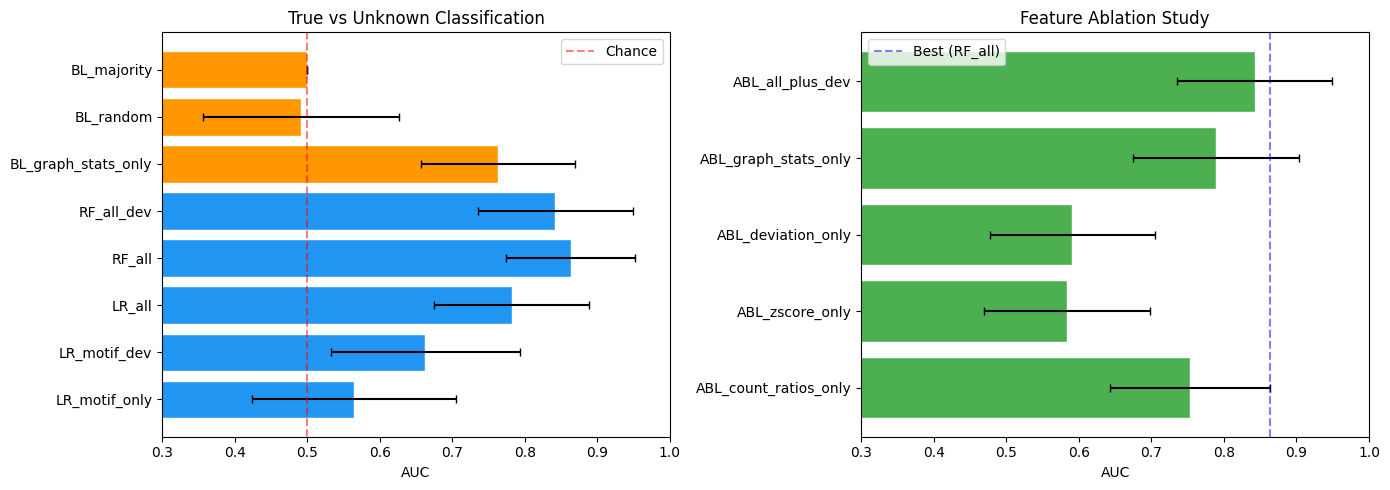

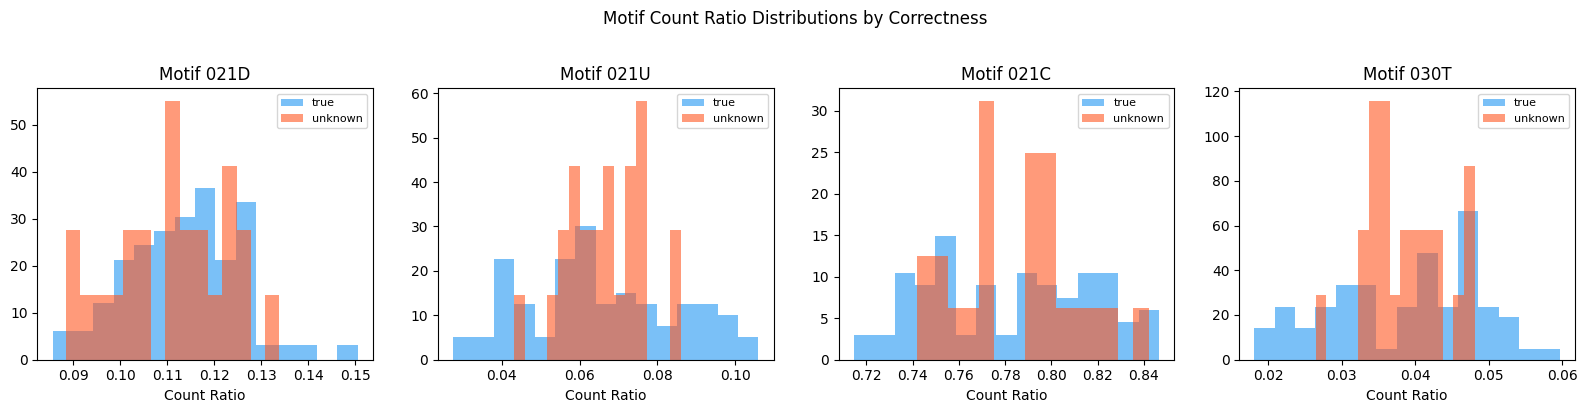


Done! Figures saved to results_comparison.png and motif_distributions.png


In [12]:
# ── Results Summary Table ──
print("=" * 70)
print("PRIMARY CLASSIFICATION RESULTS (true vs unknown)")
print("=" * 70)
print(f"{'Classifier':<25s}  {'AUC':>8s}  {'Std':>8s}  {'F1':>8s}  {'Folds':>6s}")
print("-" * 62)
for name in list(all_clf_results.keys()):
    r = all_clf_results[name]
    print(f"{name:<25s}  {r['auc_mean']:8.3f}  {r['auc_std']:8.3f}  {r.get('f1_mean',0):8.3f}  {r['n_folds']:6d}")

print(f"\nBest model: {best_clf_name} (AUC={all_clf_results[best_clf_name]['auc_mean']:.3f})")
print(f"Permutation p-value: {perm_result['empirical_p_value']:.4f}")
print(f"Bootstrap 95% CI: [{bootstrap_ci['ci_lower']:.3f}, {bootstrap_ci['ci_upper']:.3f}]")

# ── Bar Chart: AUC comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Primary classification AUC
names = list(all_clf_results.keys())
aucs = [all_clf_results[n]["auc_mean"] for n in names]
stds = [all_clf_results[n]["auc_std"] for n in names]
colors = ["#2196F3" if not n.startswith("BL_") else "#FF9800" for n in names]
bars = axes[0].barh(names, aucs, xerr=stds, color=colors, edgecolor="white", capsize=3)
axes[0].set_xlabel("AUC")
axes[0].set_title("True vs Unknown Classification")
axes[0].axvline(x=0.5, color="red", linestyle="--", alpha=0.5, label="Chance")
axes[0].set_xlim(0.3, 1.0)
axes[0].legend()

# Plot 2: Ablation study
abl_names = list(ablation_results.keys())
abl_aucs = [ablation_results[n]["auc_mean"] for n in abl_names]
abl_stds = [ablation_results[n]["auc_std"] for n in abl_names]
axes[1].barh(abl_names, abl_aucs, xerr=abl_stds, color="#4CAF50", edgecolor="white", capsize=3)
axes[1].axvline(x=all_clf_results[best_clf_name]["auc_mean"], color="blue", linestyle="--",
                alpha=0.5, label=f"Best ({best_clf_name})")
axes[1].set_xlabel("AUC")
axes[1].set_title("Feature Ablation Study")
axes[1].set_xlim(0.3, 1.0)
axes[1].legend()

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

# ── Motif distribution by correctness ──
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
motif_labels = ["021D", "021U", "021C", "030T"]
for j, (ax, label) in enumerate(zip(axes, motif_labels)):
    true_vals = X_base[y_binary == 0, j]
    unknown_vals = X_base[y_binary == 1, j]
    ax.hist(true_vals, bins=15, alpha=0.6, label="true", color="#2196F3", density=True)
    ax.hist(unknown_vals, bins=15, alpha=0.6, label="unknown", color="#FF5722", density=True)
    ax.set_title(f"Motif {label}")
    ax.set_xlabel("Count Ratio")
    ax.legend(fontsize=8)
plt.suptitle("Motif Count Ratio Distributions by Correctness", y=1.02)
plt.tight_layout()
plt.savefig("motif_distributions.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nDone! Figures saved to results_comparison.png and motif_distributions.png")